# Kalantar et al. (2025) — Table 2 validation

Scores the **110-series** ORCA runs against Table 2 of Kalantar, Hofmann, Ji, Blöcher,
Muhl, Zang & Deon (2025), *JGR Solid Earth* **130**, e2025JB031938 — shear (OG-SH),
tensile (OG-T) and saw-cut (OG-SC) fractures in Odenwald granodiorite.

This is the Kalantar counterpart of `YeGhasemmi2018/All_fracture_samples_validation_comparison.ipynb`,
but the reference data is a different *kind* of thing and the notebook is shaped accordingly:

| | Ye & Ghassemi (2018) | Kalantar et al. (2025) |
|---|---|---|
| reference | digitised continuous curves | **Table 2, 39 discrete hold stages** |
| channels | σ'ₙ, τ, Q, d_n, d_s | σ'ₙ, τ, Q, k, a_h, ΔL_s |
| independent measurements | 3–4 | **2** (see §5) |

So there is no curve-overlay section here. Everything is sampled *at the end of each
hold plateau*, exactly as `scripts/kalantar_gate.py` does, and compared stage by stage.

### Three things to know before reading any number

1. **σ₃ = 33 MPa, not the 30 MPa in the prose.** 30 is the *effective* confining
   pressure. Recovered from Table 2 by the angle identity `tan θ = (σ'ₙ − σ₃ + P_p)/τ`.
2. **OG-T's stresses are re-reduced from 25.999° to 28°.** Table 2's reduction angle
   for OG-T is geometrically impossible in a 100 mm core; Table 1's 28° is right and
   the reduction is wrong. σ₁ − σ₃ is frame-free, so it is recovered from the printed
   τ and re-projected.
3. **Only two of Table 2's six columns are independent.** §5 shows why, and why
   scoring all of them would count one defect three times.

## 1. Setup

In [45]:
from pathlib import Path
import math, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

STUDY_DIR = Path.cwd() if Path.cwd().name == "Kalantar2025" else Path("Examples/Kalantar2025")
PROJECT_ROOT = STUDY_DIR.parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

# The gate is the single source of truth for how a run is read. Importing it rather
# than re-implementing the stage walk means the notebook and the gate can never drift.
import kalantar_gate as KG

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "legend.frameon": False, "figure.constrained_layout.use": True,
})

SPECIMENS = ["OG-SH", "OG-T", "OG-SC"]
print(f"study dir : {STUDY_DIR}")
print(f"gate      : {Path(KG.__file__).relative_to(PROJECT_ROOT)}")

study dir : /media/geomechanics/Data4TB/projects/orca_4.0/Examples/Kalantar2025
gate      : scripts/kalantar_gate.py


## 2. The reference: Table 2

`KG.reference()` returns Table 2 for one specimen already re-reduced into the deck's
fracture angle. The columns are renamed to the model's channel names so the two can be
compared directly:

| Table 2 | notebook | meaning |
|---|---|---|
| `sigma_n_eff_MPa` | `sigma_n_MPa` | effective normal stress on the fracture |
| `tau_MPa` | `tau_MPa` | shear stress on the fracture |
| `Q_ml_min` | `Q_ml_min` | volumetric flow rate |
| `a_h_um` | `ah_um` | hydraulic aperture |
| `dLs_mm` | `ds_mm` | **axial** shortening from slip (not in-plane slip) |

In [46]:
REF = {s: KG.reference(s) for s in SPECIMENS}

for s in SPECIMENS:
    r = REF[s]
    printed = pd.read_csv(KG.TABLE2_CSV, comment="#").query("sample == @s").reset_index(drop=True)
    dt = 100 * (r["tau_MPa"] - printed["tau_MPa"]) / printed["tau_MPa"]
    print(f"{s:6s}  {len(r):2d} stages, P_i {r.Pi_MPa.min():.0f}-{r.Pi_MPa.max():.0f} MPa, "
          f"theta {KG.THETA_TABLE2[s]:.3f} -> {KG.THETA_DECK[s]:.1f} deg, "
          f"tau shifted by {dt.mean():+.2f} %")

display(REF["OG-SH"][["stage", "branch", "Pi_MPa", "sigma_n_MPa", "tau_MPa",
                      "Q_ml_min", "k_D", "ah_um", "ds_mm"]].round(3))

OG-SH    9 stages, P_i 6-18 MPa, theta 29.000 -> 29.0 deg, tau shifted by +0.00 %
OG-T    17 stages, P_i 6-30 MPa, theta 25.999 -> 28.0 deg, tau shifted by +5.21 %
OG-SC   13 stages, P_i 6-24 MPa, theta 30.000 -> 30.0 deg, tau shifted by +0.00 %


,stage,branch,Pi_MPa,sigma_n_MPa,tau_MPa,Q_ml_min,k_D,ah_um,ds_mm
0,1,pressurization,6,42.990,26.14,1.026,2.03,4.87,0.002
1,2,pressurization,9,40.852,24.99,1.695,1.79,4.56,0.009
2,3,pressurization,12,38.460,23.38,2.149,1.60,4.31,0.018
3,4,pressurization,15,35.879,21.43,2.797,1.58,4.27,0.029
4,5,pressurization,18,33.348,19.57,3.614,1.61,4.33,0.039
5,6,depressurization,15,34.632,19.18,2.262,1.37,3.98,0.041
6,7,depressurization,12,36.093,19.11,1.573,1.30,3.88,0.042
7,8,depressurization,9,37.549,19.03,0.966,1.23,3.78,0.042
8,9,depressurization,6,39.015,18.97,0.461,1.19,3.72,0.042


## 3. Is Table 2 self-consistent?

The paper prints both an input (`Q`) and two quantities derived from it (`k`, `a_h`),
so the derivation is a **testable claim, not a given**. Two checks:

* **`a_h` vs `k`** — the paper's own definition is `a_h = sqrt(12 k)`.
* **`Q` vs `a_h`** — the plane cubic law `a_h^3 = (Q eta / dP) * 12 * L / W` with no
  fitted constant. (Eq (7) as printed misses Table 2 by 10.3x in `a_h^3`; the factor is
  the 12, dropped from inside the cube-root bracket. See
  `doc/reading_kalantar2025_self_propping_granodiorite.md` §2.2.)

Whichever check fails tells you which column to trust — and that decides which channel
the gate should score.

In [47]:
DARCY = 9.869233e-13          # m^2 per Darcy
SEP_PAPER = {"OG-SH": 0.0824654, "OG-T": 0.0851596, "OG-SC": 0.0799600}   # in-plane L, m
W_CORE, ETA = 0.04998, 1.0e-3

rows = []
for s in SPECIMENS:
    r = REF[s]
    ah_from_k = np.sqrt(12.0 * r["k_D"] * DARCY) * 1e6                     # um
    dP = (r["Pi_MPa"] - KG.P_OUT_MPA) * 1e6                                # Pa
    q  = r["Q_ml_min"] * 1e-6 / 60.0                                       # m^3/s
    ah_from_Q = np.cbrt(q * ETA / dP * 12.0 * SEP_PAPER[s] / W_CORE) * 1e6  # um
    ok = r["Q_ml_min"] >= KG.Q_FLOOR_ML_MIN                                # printed Q is resolved
    rows.append(dict(sample=s, n=len(r), n_resolved=int(ok.sum()),
                     ah_over_ahk=(r["ah_um"] / ah_from_k).replace([np.inf, -np.inf], np.nan).mean(),
                     ah_over_ahQ=(r["ah_um"][ok] / ah_from_Q[ok]).mean(),
                     ahQ_scatter_pct=100 * (r["ah_um"][ok] / ah_from_Q[ok]).std()
                                     / (r["ah_um"][ok] / ah_from_Q[ok]).mean()))
consistency = pd.DataFrame(rows).set_index("sample")
display(consistency.round(4))

print('''
a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.
''')

,n,n_resolved,ah_over_ahk,ah_over_ahQ,ahQ_scatter_pct
sample,,,,,
OG-SH,9,9,0.9901,1.0054,0.1229
OG-T,17,8,0.8668,1.0228,3.2025
OG-SC,13,12,0.8746,0.9619,6.0825



a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.



## 4. Load the runs

Each `RUNS` entry is one model variant. Set its `specimen` to the matching Table 2
sample and choose its `color`, `linestyle`, and `marker`; entries with no CSV are
skipped everywhere below, so this notebook remains usable after a partial batch.

**A truncated CSV looks exactly like a complete one.** The table below prints the last
time reached against the deck's `end_time`, and anything short of `MIN_COMPLETE_PCT`
is **excluded from scoring** — a run that died at stage 3 would otherwise be scored on
the stages it did reach and merely look bad, rather than looking unfinished. Truncated
runs remain visible in all diagnostic figures but are never added to the scorecard.

In [48]:
# Each run owns its data paths and plotting style.  `specimen` selects the matching
# Table 2 reference, while the dictionary key is only the label shown in tables/figures.
# Add another run by copying one entry and choosing any Matplotlib color, linestyle,
# and marker (for example: colors "tab:pink"; linestyles "-.", ":"; markers "X", "*").
RUNS = {
    "OG-SH r1": dict(
        specimen="OG-SH",
        deck=STUDY_DIR / "OGSH/110_01_og_sh_bbfast_r1.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_01_og_sh_bbfast_r1_hpc.csv",
        color="#1f77b4", linestyle="-",  marker="o"),
    "OG-SH r3": dict(
        specimen="OG-SH",
        deck=STUDY_DIR / "OGSH/110_02_og_sh_bbfast_r3.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_02_og_sh_bbfast_r3_hpc.csv",
        color="#17becf", linestyle="--", marker="s"),
    "OG-T r1": dict(
        specimen="OG-T",
        deck=STUDY_DIR / "OGT/110_03_og_t_bbfast_r1.i",
        csv=STUDY_DIR / "OGT/results_csv_hpc/110_03_og_t_bbfast_r1_hpc.csv",
        color="#d62728", linestyle="-",  marker="^"),
    "OG-T r3": dict(
        specimen="OG-T",
        deck=STUDY_DIR / "OGT/110_04_og_t_bbfast_r3.i",
        csv=STUDY_DIR / "OGT/results_csv_hpc/110_04_og_t_bbfast_r3_hpc.csv",
        color="#ff7f0e", linestyle="--", marker="D"),
    "OG-SC r1": dict(
        specimen="OG-SC",
        deck=STUDY_DIR / "OGSC/110_05_og_sc_bbfast_r1.i",
        csv=STUDY_DIR / "OGSC/results_csv_hpc/110_05_og_sc_bbfast_r1_hpc.csv",
        color="#2ca02c", linestyle="-",  marker="v"),
    "OG-SC r3": dict(
        specimen="OG-SC",
        deck=STUDY_DIR / "OGSC/110_06_og_sc_bbfast_r3.i",
        csv=STUDY_DIR / "OGSC/results_csv_hpc/110_06_og_sc_bbfast_r3_hpc.csv",
        color="#9467bd", linestyle="--", marker="P"),
}

import re
def deck_end_time(deck):
    m = re.search(r"^\s*end_time\s*=\s*([0-9.eE+-]+)", deck.read_text(), re.M)
    return float(m.group(1)) if m else np.nan

MIN_COMPLETE_PCT = 99.9

# Two dicts, deliberately. SHOWN carries every run that produced a CSV and is what the
# DIAGNOSTIC sections below plot -- a truncated run is the most informative thing in a
# batch and hiding it wastes the compute that produced it. LOADED carries only runs that
# reached end_time and is what the SCORECARD uses. Scoring a truncated run is what
# produced the phantom OG-T/OG-SC scores of 54 and 85 in the 2026-08-24 batch: the stage
# walk matched 17 and 13 holds inside schedules the run never got to, by re-reading the
# last available row once per unreached stage. Keep the two dicts separate.
LOADED, SHOWN, status = {}, {}, []
for s, cfg in RUNS.items():
    row = dict(sample=s, csv=cfg["csv"].name)
    if not cfg["csv"].exists():
        status.append(dict(row, state="MISSING", rows=0, t_end=np.nan,
                           end_time=deck_end_time(cfg["deck"]) if cfg["deck"].exists() else np.nan,
                           pct=np.nan, shown=False, scored=False))
        continue
    df = (pd.read_csv(cfg["csv"]).sort_values("time")
            .drop_duplicates("time", keep="last").reset_index(drop=True))
    end   = deck_end_time(cfg["deck"])
    t_end = float(df["time"].iloc[-1])
    pct   = 100 * t_end / end if end else np.nan
    complete = pct >= MIN_COMPLETE_PCT
    SHOWN[s] = dict(cfg, df=df, end_time=end, t_end=t_end, pct=pct, complete=complete)
    if complete:
        LOADED[s] = SHOWN[s]
    status.append(dict(row, state="complete" if complete else "TRUNCATED",
                       rows=len(df), t_end=t_end, end_time=end, pct=pct,
                       shown=True, scored=complete))

display(pd.DataFrame(status).set_index("sample").round(2))
print(f"scored (complete only) : {', '.join(LOADED) or 'nothing'}")
print(f"plotted (all with CSV) : {', '.join(SHOWN)  or 'nothing'}")
trunc = [s for s, c in SHOWN.items() if not c["complete"]]
if trunc:
    print(f"\nTRUNCATED, shown but NOT scored: {', '.join(trunc)}")
    print("  Their stage tables and figures below stop at the last time the run reached.")
    print("  Do not quote an nRMSE for them -- there is no such number.")


,csv,state,rows,t_end,end_time,pct,shown,scored
sample,,,,,,,,
OG-SH r1,110_01_og_sh_bbfast_r1_hpc.csv,complete,4801,3600.00,3600.0,100.00,True,True
OG-SH r3,110_02_og_sh_bbfast_r3_hpc.csv,complete,786,3600.00,3600.0,100.00,True,True
OG-T r1,110_03_og_t_bbfast_r1_hpc.csv,TRUNCATED,6425,2620.24,6800.0,38.53,True,False
OG-T r3,110_04_og_t_bbfast_r3_hpc.csv,TRUNCATED,29,34.21,6800.0,0.50,True,False
OG-SC r1,110_05_og_sc_bbfast_r1_hpc.csv,TRUNCATED,9717,7284.28,9100.0,80.05,True,False
OG-SC r3,110_06_og_sc_bbfast_r3_hpc.csv,complete,1935,9100.00,9100.0,100.00,True,True


scored (complete only) : OG-SH r1, OG-SH r3, OG-SC r3
plotted (all with CSV) : OG-SH r1, OG-SH r3, OG-T r1, OG-T r3, OG-SC r1, OG-SC r3

TRUNCATED, shown but NOT scored: OG-T r1, OG-T r3, OG-SC r1
  Their stage tables and figures below stop at the last time the run reached.
  Do not quote an nRMSE for them -- there is no such number.


## 5. Why only two channels are scored

The rig runs at **constant piston displacement**. Eq (6) with `dL = 0`, combined with
eq (4), gives an algebraic identity — not a correlation:

$$\Delta L_s = -\,\frac{A\,\Delta\tau}{K_{sys}\sin\theta\cos\theta}$$

and σ'ₙ and τ are both affine in σ₁. So **σ'ₙ, τ and ΔL_s are three readouts of one
force measurement.** Table 2 holds a *force* measurement and a *flow* measurement, and
nothing else.

The gate therefore scores one force channel (τ) and one flow channel, and prints the
rest as diagnostics. ΔL_s in particular is a **frame check**: with `axial_bc_penalty`
set to `K_sys/A`, any deck that gets τ(t) right gets ΔL_s(t) free. The cell below prints
the identity's predicted slope beside what Table 2 actually does.

In [49]:
frame = []
for s in SPECIMENS:
    r = REF[s]
    pred = KG.expected_dtau_dls(s)                      # MPa per um of axial shortening
    # Fit over stages where dL_s actually moves; a flat column has no slope to fit.
    ds_um = r["ds_mm"].to_numpy() * 1e3
    tau   = r["tau_MPa"].to_numpy()
    move  = np.ptp(ds_um) > 2.0
    slope = -np.polyfit(ds_um, tau, 1)[0] if move else np.nan
    rr    = np.corrcoef(ds_um, tau)[0, 1] if move else np.nan
    frame.append(dict(sample=s, predicted_MPa_per_um=pred, fitted=slope,
                      ratio=slope / pred if move else np.nan, r=rr,
                      dLs_span_um=np.ptp(ds_um), one_over_cos=1/math.cos(math.radians(KG.THETA_DECK[s]))))
display(pd.DataFrame(frame).set_index("sample").round(4))

print('''
ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.
''')

,predicted_MPa_per_um,fitted,ratio,r,dLs_span_um,one_over_cos
sample,,,,,,
OG-SH,0.1720,0.1792,1.0416,-0.9998,40.0,1.1434
OG-T,0.1682,0.1682,0.9999,-1.0000,275.0,1.1326
OG-SC,0.1757,0.1750,0.9962,-0.9996,22.0,1.1547



ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.



## 6. Scorecard

`KG.score()` walks the deck's own injection schedule, finds each Table-2 hold plateau,
and samples the last output row at or before the end of the hold.

* `nRMSE %` is normalised by the **span** of the measured column, so a channel that
  barely moves in the experiment is judged on a correspondingly tight scale.
* `bias` is mean(model − measured). A large bias with small scatter is a *level* error
  (usually loading or an anchor constant); scatter with no bias is a *shape* error
  (usually the constitutive law).
* `*` marks the two scored channels; the mean is over those only.

In [50]:
SCORES = {}
for s, cfg in LOADED.items():
    try:
        SCORES[s] = KG.score(cfg["csv"], cfg["specimen"], cfg["deck"], tol_mpa=0.15)
    except SystemExit as exc:
        print(f"{s}: gate could not walk the stages -- {exc}")

rows = []
for s, res in SCORES.items():
    for key, c in res["channels"].items():
        if c is None:
            continue
        rows.append(dict(sample=s, channel=key, scored=key in res["scored"],
                         n=c["n"], dropped=c["dropped"], nrmse_pct=c["nrmse_pct"],
                         mae=c["mae"], bias=c["bias"], source=res["used"].get(key, "?")))
scorecard = pd.DataFrame(rows)
if not scorecard.empty:
    display(scorecard.set_index(["sample", "channel"]).round(3))
    mean = (scorecard[scorecard.scored].groupby("sample")["nrmse_pct"].mean()
            .rename("mean nRMSE % (scored only)"))
    display(mean.round(2).to_frame())
    print("\nReproducibility floor is 0.1 pp of mean nRMSE -- do not rank runs inside it.")

scored   n  dropped  nrmse_pct    mae   bias  \
sample   channel                                                     
OG-SH r1 tau_MPa        True   9        0     68.365  4.289  4.255   
         Q_ml_min       True   9        0     65.758  1.875  1.875   
         sigma_n_MPa   False   9        0     28.181  2.377  2.358   
         ah_um         False   9        0     58.670  0.601  0.601   
         ds_mm         False   9        0     73.650  0.030 -0.030   
OG-SH r3 tau_MPa        True   9        0     21.227  1.400  1.287   
         Q_ml_min       True   9        0     13.245  0.265 -0.205   
         sigma_n_MPa   False   9        0      8.750  0.776  0.713   
         ah_um         False   9        0     19.129  0.159 -0.112   
         ds_mm         False   9        0     14.170  0.006  0.004   
OG-SC r3 tau_MPa        True  13        0    115.797  3.509 -3.472   
         ah_um          True  13        0     38.960  0.443 -0.432   
         sigma_n_MPa   False  13        0     23.502  2.026 -2.004   
         Q_ml_min      False  12        1     34.479  0.106 -0.106   
         ds_mm         False  13        0    248.164  0.050  0.050   

                                                   source  
sample   channel                                           
OG-SH r1 tau_MPa          shear_stress_paper_frame_mpa_pp  
         Q_ml_min          flow_rate_validation_ml_min_pp  
         sigma_n_MPa  effective_normal_paper_frame_mpa_pp  
         ah_um                   hydraulic_aperture_um_pp  
         ds_mm              reported_czm_shear_slip_mm_pp  
OG-SH r3 tau_MPa          shear_stress_paper_frame_mpa_pp  
         Q_ml_min          flow_rate_validation_ml_min_pp  
         sigma_n_MPa  effective_normal_paper_frame_mpa_pp  
         ah_um                   hydraulic_aperture_um_pp  
         ds_mm              reported_czm_shear_slip_mm_pp  
OG-SC r3 tau_MPa          shear_stress_paper_frame_mpa_pp  
         ah_um                   hydraulic_aperture_um_pp  
         sigma_n_MPa  effective_normal_paper_frame_mpa_pp  
         Q_ml_min          flow_rate_validation_ml_min_pp  
         ds_mm              reported_czm_shear_slip_mm_pp

,mean nRMSE % (scored only)
sample,
OG-SC r3,77.38
OG-SH r1,67.06
OG-SH r3,17.24



Reproducibility floor is 0.1 pp of mean nRMSE -- do not rank runs inside it.


## 7. Stage-by-stage tables

In [51]:
def stage_table(sample):
    '''Measured vs modelled at every hold the run actually reached, for one specimen.'''
    cfg = SHOWN[sample]
    specimen = cfg["specimen"]
    ref = REF[specimen]
    x, y = KG.parse_schedule(cfg["deck"])
    times = KG.kal_stage_times(x, y, ref, 0.15)

    # Clip to the last time the run reached. Without this a truncated run silently
    # re-reads its final row once per unreached stage and every one of them looks
    # merely "wrong" rather than "absent".
    t_end = cfg["t_end"]
    reached = [t for t in times if t <= t_end + 1e-9]
    n_missing = len(times) - len(reached)

    df = cfg["df"]
    cos_t = math.cos(math.radians(KG.THETA_DECK[specimen]))

    got = pd.DataFrame([df[df.time <= t + 1e-9].iloc[-1] for t in reached
                        if not df[df.time <= t + 1e-9].empty]).reset_index(drop=True)
    out = pd.DataFrame({"stage": ref["stage"][:len(got)], "branch": ref["branch"][:len(got)],
                        "Pi": ref["Pi_MPa"][:len(got)], "t_s": reached[:len(got)]})
    for key, label in [("sigma_n_MPa", "sn"), ("tau_MPa", "tau"),
                       ("ah_um", "ah"), ("Q_ml_min", "Q"), ("ds_mm", "ds")]:
        series, _ = KG.first_column(got, KG.KAL_COLUMNS[key])
        meas = ref[key].to_numpy()[:len(got)].astype(float)
        if key == "ds_mm":
            meas = meas / cos_t          # axial shortening -> in-plane slip
        out[f"{label}_meas"] = meas
        out[f"{label}_sim"]  = np.nan if series is None else np.asarray(series, float)
        out[f"{label}_err%"] = 100 * (out[f"{label}_sim"] - out[f"{label}_meas"]) / \
                               out[f"{label}_meas"].replace(0, np.nan)
    out.attrs["n_missing"] = n_missing
    out.attrs["complete"]  = cfg["complete"]
    return out.round(3)

STAGE_TABLES = {}
for s in SHOWN:
    STAGE_TABLES[s] = stage_table(s)
    tag = "" if SHOWN[s]["complete"] else (
        f"   [TRUNCATED at {SHOWN[s]['t_end']:.0f} s of {SHOWN[s]['end_time']:.0f} s "
        f"= {SHOWN[s]['pct']:.1f} %; {STAGE_TABLES[s].attrs['n_missing']} of "
        f"{STAGE_TABLES[s].attrs['n_missing'] + len(STAGE_TABLES[s])} stages never reached -- "
        f"NOT SCORED]")
    print(f"\n===== {s}{tag}")
    display(STAGE_TABLES[s])



===== OG-SH r1


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,400.0,42.990,42.904,-0.200,26.14,25.985,-0.594,4.87,4.871,0.018,1.026,1.410,37.398,0.002,0.003,13.623
1,2,pressurization,9,800.0,40.852,41.324,1.155,24.99,25.841,3.406,4.56,4.873,6.868,1.695,2.823,66.575,0.010,0.003,-74.918
2,3,pressurization,12,1200.0,38.460,39.786,3.448,23.38,25.772,10.233,4.31,4.877,13.147,2.149,4.244,97.494,0.021,0.003,-87.488
3,4,pressurization,15,1600.0,35.879,38.234,6.564,21.43,25.679,19.826,4.27,4.853,13.644,2.797,5.576,99.343,0.033,0.003,-91.357
4,5,pressurization,18,2000.0,33.348,36.624,9.824,19.57,25.480,30.201,4.33,4.736,9.386,3.614,6.481,79.324,0.045,0.005,-88.952
5,6,depressurization,15,2400.0,34.632,38.098,10.008,19.18,25.433,32.601,3.98,4.731,18.864,2.262,5.166,128.393,0.047,0.005,-89.500
6,7,depressurization,12,2800.0,36.093,39.563,9.616,19.11,25.371,32.763,3.88,4.727,21.821,1.573,3.865,145.679,0.048,0.005,-89.764
7,8,depressurization,9,3200.0,37.549,41.025,9.259,19.03,25.302,32.958,3.78,4.724,24.962,0.966,2.571,166.179,0.048,0.005,-89.780
8,9,depressurization,6,3600.0,39.015,42.484,8.891,18.97,25.228,32.987,3.72,4.721,26.915,0.461,1.284,178.470,0.048,0.005,-89.797



===== OG-SH r3


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,400.0,42.990,42.709,-0.653,26.14,25.634,-1.938,4.87,4.859,-0.235,1.026,1.043,1.623,0.002,0.003,22.851
1,2,pressurization,9,800.0,40.852,41.056,0.499,24.99,25.358,1.471,4.56,4.704,3.168,1.695,1.893,11.688,0.010,0.005,-49.324
2,3,pressurization,12,1200.0,38.460,38.968,1.322,23.38,24.297,3.924,4.31,4.183,-2.944,2.149,1.996,-7.104,0.021,0.017,-17.180
3,4,pressurization,15,1600.0,35.879,36.719,2.342,21.43,22.946,7.073,4.27,3.915,-8.304,2.797,2.183,-21.961,0.033,0.034,1.112
4,5,pressurization,18,2000.0,33.348,34.264,2.747,19.57,21.223,8.444,4.33,3.844,-11.226,3.614,2.582,-28.563,0.045,0.055,23.908
5,6,depressurization,15,2400.0,34.632,35.720,3.142,19.18,21.143,10.235,3.98,3.818,-4.068,2.262,2.024,-10.521,0.047,0.055,17.848
6,7,depressurization,12,2800.0,36.093,37.163,2.965,19.11,21.040,10.102,3.88,3.799,-2.076,1.573,1.496,-4.902,0.048,0.055,15.022
7,8,depressurization,9,3200.0,37.549,38.601,2.804,19.03,20.929,9.981,3.78,3.788,0.213,0.966,0.988,2.311,0.048,0.055,15.000
8,9,depressurization,6,3600.0,39.015,40.037,2.619,18.97,20.814,9.718,3.72,3.781,1.627,0.461,0.491,6.553,0.048,0.055,14.977



===== OG-T r1   [TRUNCATED at 2620 s of 6800 s = 38.5 %; 11 of 17 stages never reached -- NOT SCORED]


...

,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%



===== OG-SC r1   [TRUNCATED at 7284 s of 9100 s = 80.0 %; 3 of 13 stages never reached -- NOT SCORED]


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,700.0,36.098,36.088,-0.027,13.16,13.143,-0.129,1.03,1.032,0.171,0.018,0.010,-42.789,0.000,0.001,NaN
1,2,pressurization,9,1400.0,34.586,34.562,-0.070,13.14,13.098,-0.317,1.18,1.037,-12.095,0.041,0.021,-48.956,0.000,0.001,NaN
2,3,pressurization,12,2100.0,33.075,33.015,-0.181,13.12,13.016,-0.792,1.23,1.017,-17.297,0.062,0.030,-52.245,0.000,0.002,NaN
3,4,pressurization,15,2800.0,31.552,28.477,-9.744,13.08,7.755,-40.712,1.36,0.670,-50.703,0.104,0.011,-89.133,0.001,0.061,5142.756
4,5,pressurization,18,3500.0,30.017,26.511,-11.679,13.02,6.948,-46.638,1.53,0.731,-52.242,0.169,0.018,-89.178,0.001,0.072,6143.300
5,6,pressurization,21,4200.0,28.477,24.421,-14.241,12.95,5.926,-54.240,1.60,0.860,-46.271,0.222,0.036,-83.901,0.001,0.087,7448.095
6,7,pressurization,24,4900.0,25.118,22.300,-11.218,9.73,4.850,-50.159,1.92,1.082,-43.660,0.438,0.083,-81.033,0.023,0.104,352.141
7,8,depressurization,21,5600.0,26.595,23.622,-11.176,9.69,4.542,-53.126,1.67,0.914,-45.246,0.252,0.043,-82.932,0.023,0.104,352.010
8,9,depressurization,18,6300.0,28.037,24.949,-11.013,9.59,4.242,-55.765,1.52,0.798,-47.513,0.161,0.024,-85.214,0.023,0.104,351.880
9,10,depressurization,15,7000.0,29.485,26.307,-10.776,9.50,3.997,-57.931,1.36,0.729,-46.422,0.100,0.015,-85.490,0.024,0.104,330.261



===== OG-SC r3


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,700.0,36.098,36.088,-0.028,13.16,13.143,-0.131,1.03,1.032,0.171,0.018,0.010,-42.789,0.000,0.001,NaN
1,2,pressurization,9,1400.0,34.586,34.563,-0.069,13.14,13.099,-0.314,1.18,1.037,-12.095,0.041,0.021,-48.956,0.000,0.001,NaN
2,3,pressurization,12,2100.0,33.075,33.065,-0.031,13.12,13.102,-0.134,1.23,1.046,-14.987,0.062,0.032,-48.129,0.000,0.001,NaN
3,4,pressurization,15,2800.0,31.552,31.589,0.118,13.08,13.144,0.491,1.36,1.058,-22.220,0.104,0.044,-57.316,0.001,0.001,14.060
4,5,pressurization,18,3500.0,30.017,30.120,0.342,13.02,13.198,1.364,1.53,1.056,-30.995,0.169,0.055,-67.355,0.001,0.002,33.262
5,6,pressurization,21,4200.0,28.477,24.435,-14.194,12.95,5.949,-54.060,1.60,0.855,-46.557,0.222,0.035,-84.157,0.001,0.085,7300.961
6,7,pressurization,24,4900.0,25.118,22.300,-11.217,9.73,4.850,-50.152,1.92,1.081,-43.707,0.438,0.083,-81.080,0.023,0.104,350.065
7,8,depressurization,21,5600.0,26.595,23.638,-11.117,9.69,4.569,-52.845,1.67,0.913,-45.324,0.252,0.043,-83.005,0.023,0.104,349.941
8,9,depressurization,18,6300.0,28.037,24.971,-10.936,9.59,4.279,-55.376,1.52,0.797,-47.579,0.161,0.024,-85.270,0.023,0.104,349.814
9,10,depressurization,15,7000.0,29.485,26.331,-10.696,9.50,4.038,-57.499,1.36,0.728,-46.472,0.100,0.014,-85.531,0.024,0.104,328.295


## 8. Channel-by-channel figures

Color, line style, and open-marker shape identify the model run (as configured in
`RUNS`). Filled black circles are Table 2 at the end of each hold. The vertical gap
between a filled reference point and an open model point *is* the stage error.

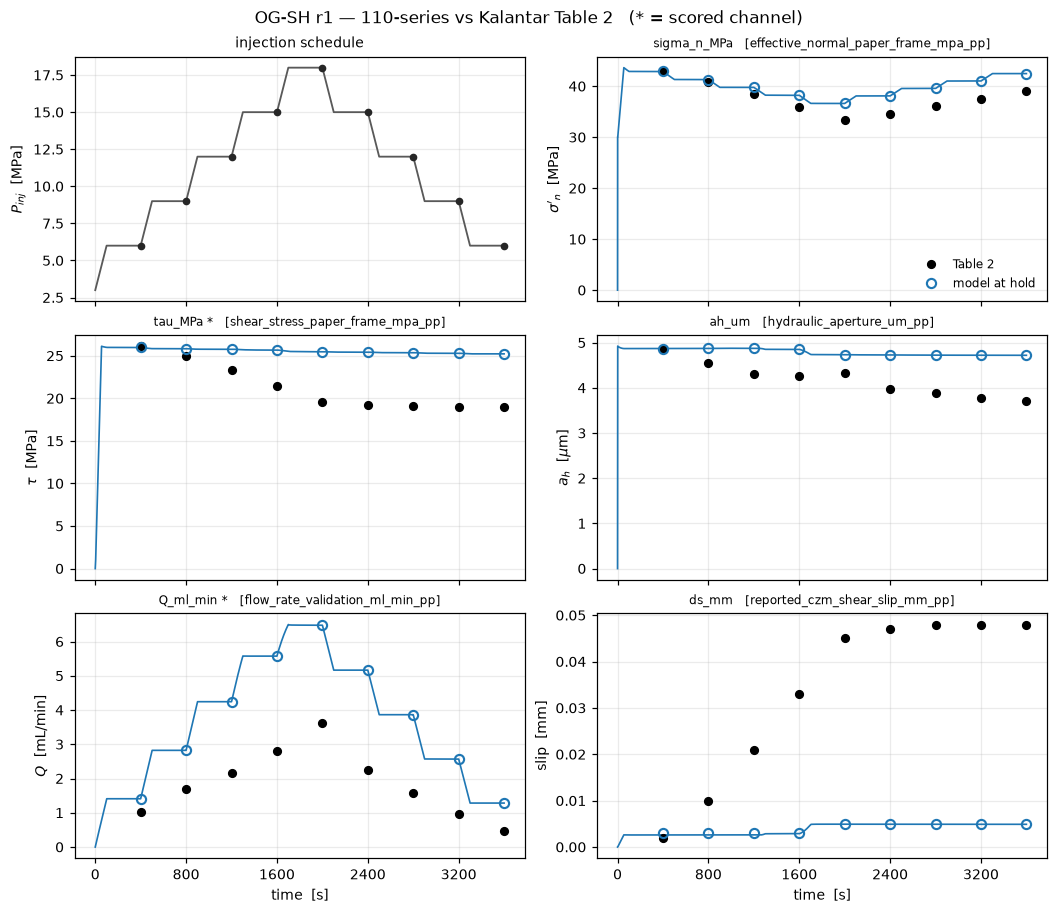

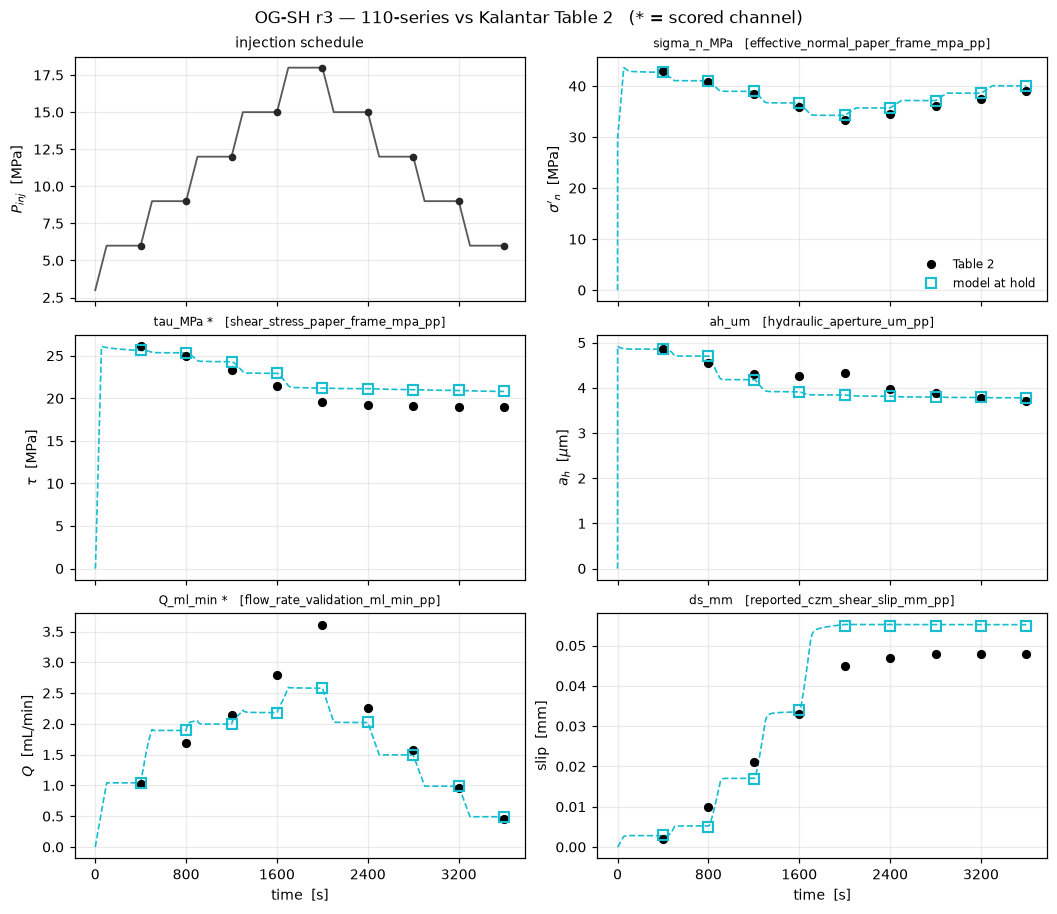

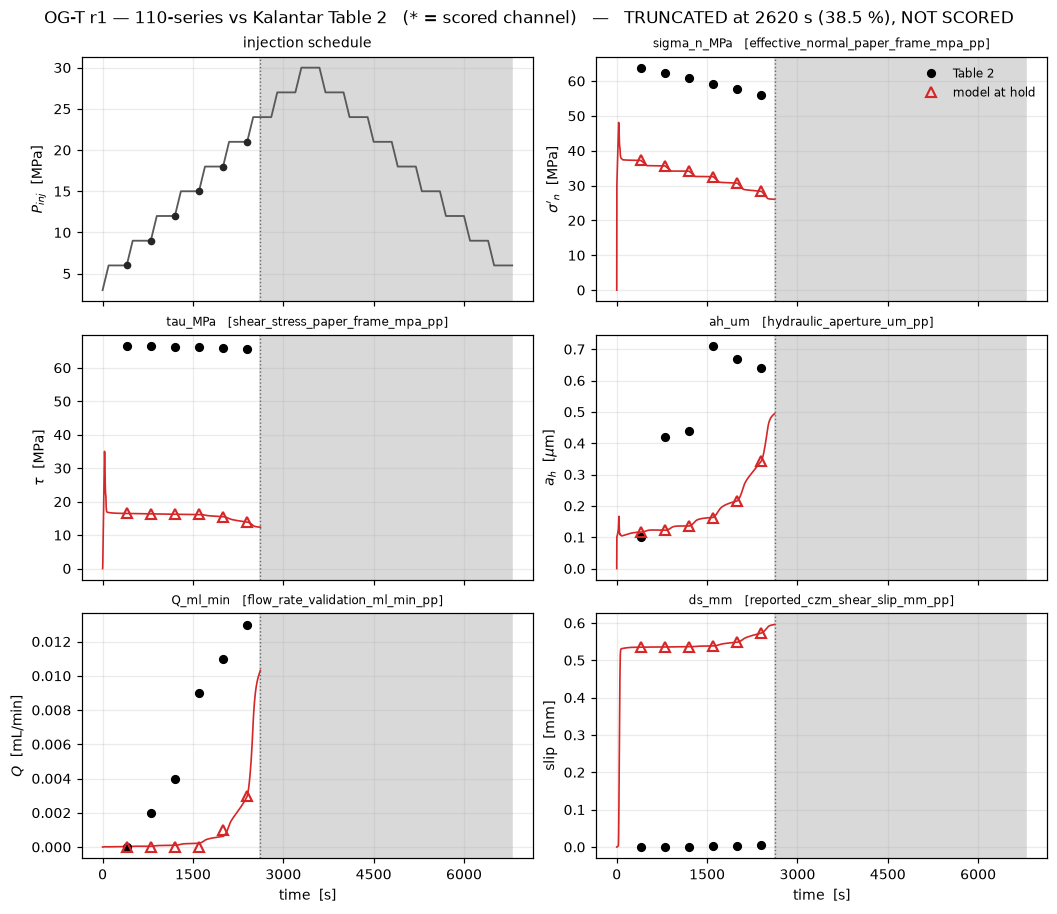

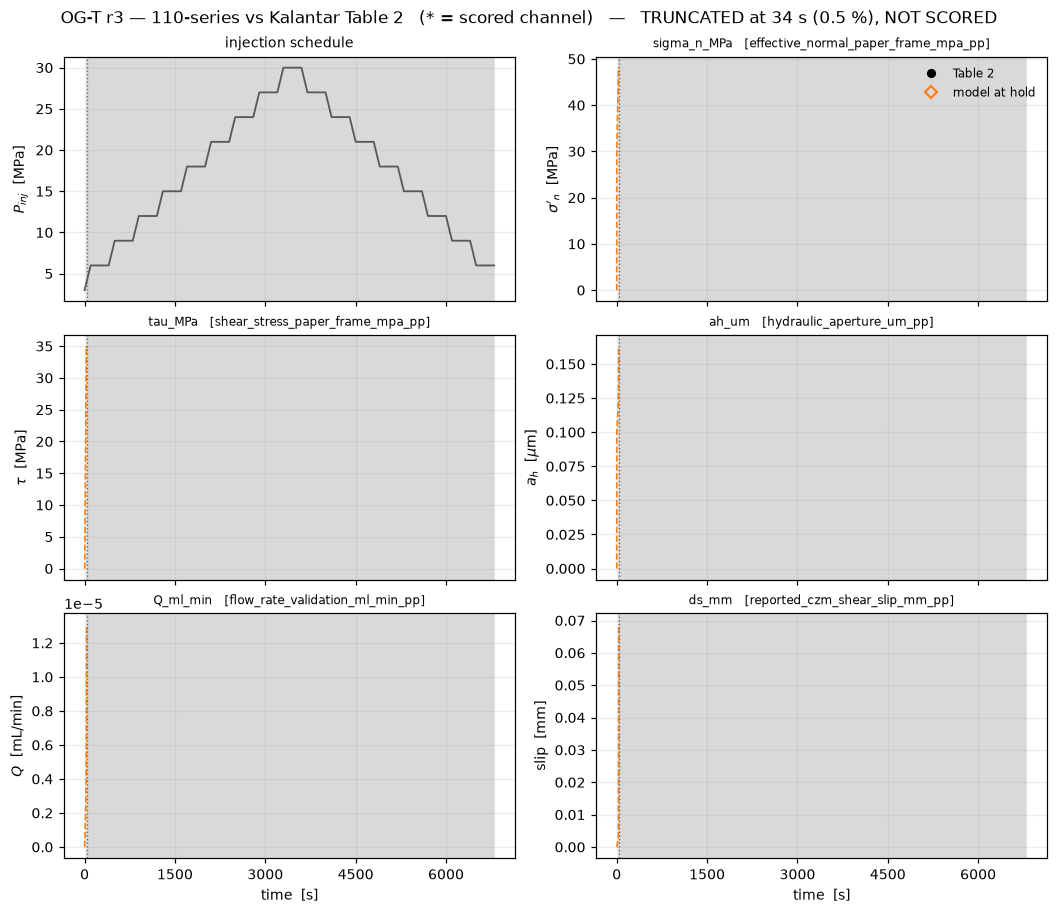

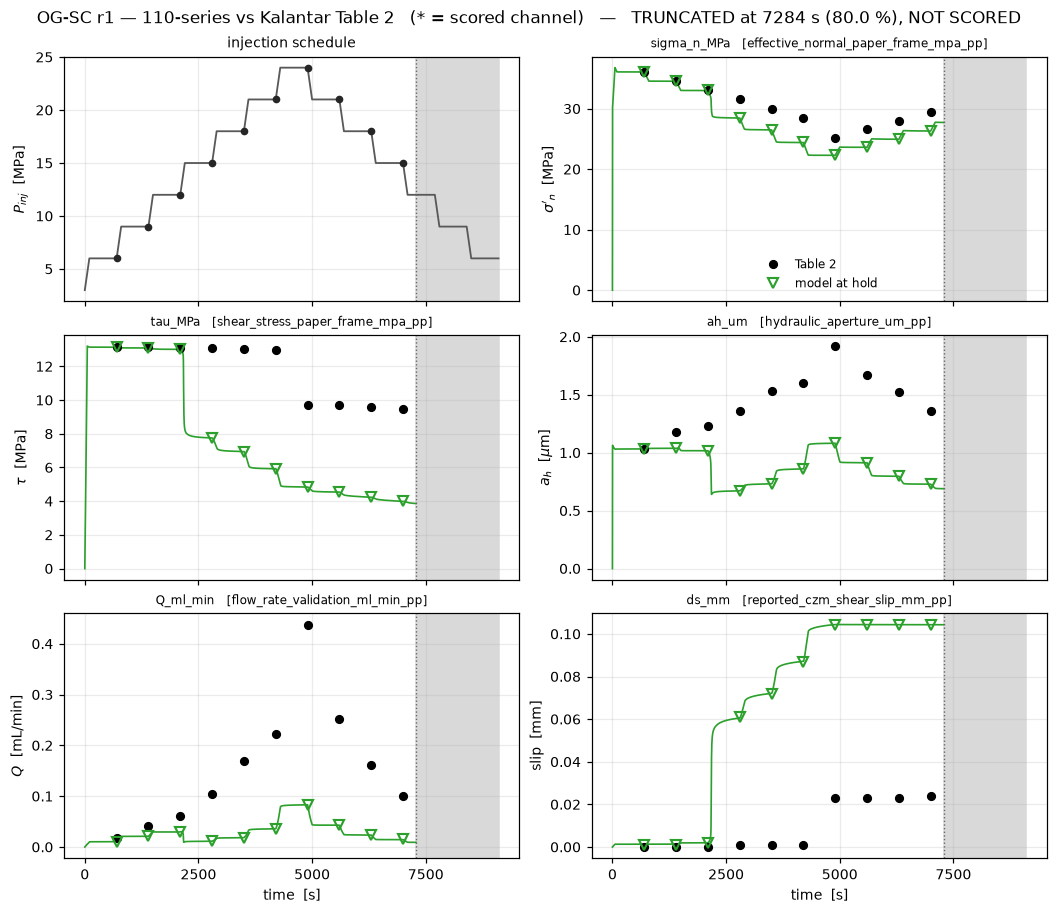

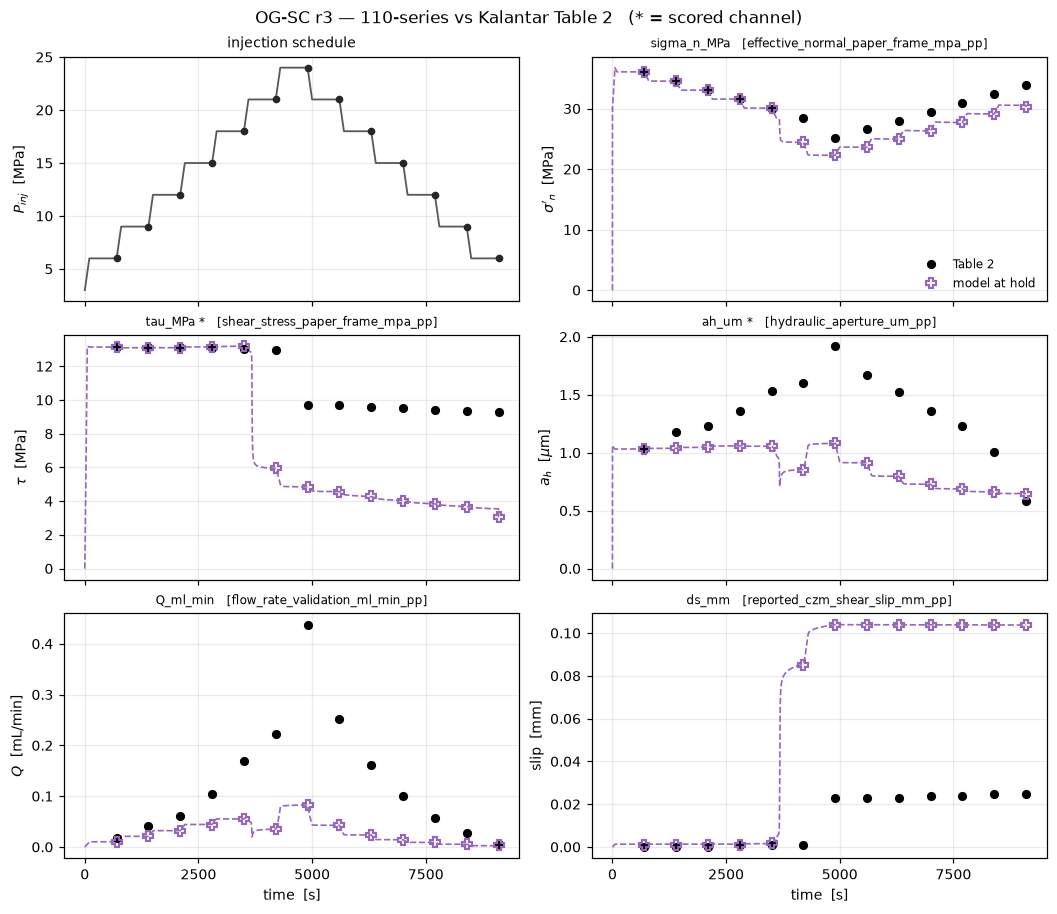

In [52]:
CHANNELS = [("sigma_n_MPa", "sn", r"$\sigma'_n$  [MPa]"),
            ("tau_MPa",     "tau", r"$\tau$  [MPa]"),
            ("ah_um",       "ah",  r"$a_h$  [$\mu$m]"),
            ("Q_ml_min",    "Q",   r"$Q$  [mL/min]"),
            ("ds_mm",       "ds",  r"slip  [mm]")]

def plot_channels(sample):
    cfg, tab = SHOWN[sample], STAGE_TABLES[sample]
    df, res = cfg["df"], SCORES.get(sample)
    scored = set(res["scored"]) if res else set()
    fig, axes = plt.subplots(3, 2, figsize=(9.5, 8.2), sharex=True)
    x, y = KG.parse_schedule(cfg["deck"])

    ax = axes.flat[0]
    ax.plot(x, y, color="0.35", lw=1.2)
    ax.plot(tab["t_s"], tab["Pi"], "o", ms=4, color="0.15")
    ax.set_ylabel(r"$P_{inj}$  [MPa]"); ax.set_title("injection schedule", fontsize=9)

    for ax, (key, label, ylab) in zip(axes.flat[1:], CHANNELS):
        series, name = KG.first_column(df, KG.KAL_COLUMNS[key])
        if series is not None:
            ax.plot(df["time"], series, lw=1.1, color=cfg["color"],
                    linestyle=cfg["linestyle"])
        ax.plot(tab["t_s"], tab[f"{label}_meas"], "o", ms=5, color="k",
                label="Table 2", zorder=5)
        ax.plot(tab["t_s"], tab[f"{label}_sim"], linestyle="none",
                marker=cfg["marker"], ms=6, mfc="none", mec=cfg["color"],
                mew=1.4, label="model at hold", zorder=6)
        star = " *" if key in scored else ""
        ax.set_ylabel(ylab)
        ax.set_title(f"{key}{star}" + (f"   [{name}]" if name else "   [not emitted]"),
                     fontsize=8)
        ax.xaxis.set_major_locator(MaxNLocator(5))
    axes.flat[1].legend(loc="best", fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("time  [s]")
    # Grey out the part of the schedule the run never reached, on every panel, so a
    # truncated run cannot be mistaken for a model that simply flattened out.
    if not cfg["complete"]:
        for ax in axes.flat:
            ax.axvspan(cfg["t_end"], cfg["end_time"], color="0.85", zorder=0)
            ax.axvline(cfg["t_end"], color="0.4", lw=0.9, ls=":")
    tag = "" if cfg["complete"] else (f"   —   TRUNCATED at {cfg['t_end']:.0f} s "
                                      f"({cfg['pct']:.1f} %), NOT SCORED")
    fig.suptitle(f"{sample} — 110-series vs Kalantar Table 2   "
                 f"(* = scored channel){tag}", fontsize=11)
    return fig

CHANNEL_FIGS = {s: plot_channels(s) for s in SHOWN}
plt.show()

## 9. Stress path and the failure envelope

The experiment walks *down and left* in (σ'ₙ, τ) as injection raises pore pressure: σ'ₙ
falls, and τ falls too once the joint slips. Plotting the model's path against the
measurement together with the deck's own Barton–Bandis envelope shows immediately
whether a miss is a **loading** problem (path in the wrong place) or a **strength**
problem (path right, envelope wrong).

The envelope drawn is the deck's peak criterion
`tau = sigma'_n tan[phi_r + JRC log10(JCS/sigma'_n)] + c`, read straight out of the deck.

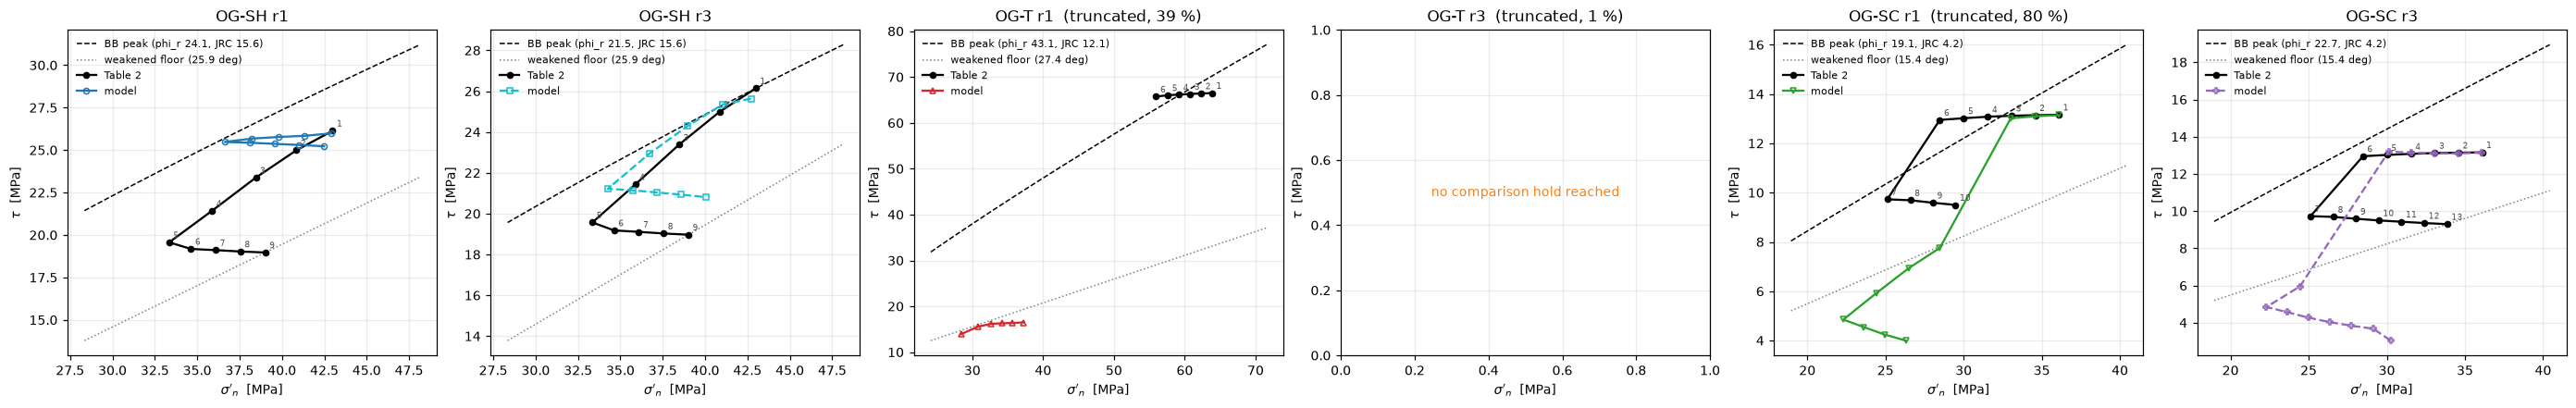

In [53]:
def deck_params(deck):
    t = deck.read_text()
    def grab(k, default=np.nan):
        m = re.search(rf"^\s+{k}\s*=\s*([0-9.eE+-]+)", t, re.M)
        return float(m.group(1)) if m else default
    return dict(jrc=grab("jrc"), jcs=grab("jcs"), phi_r=grab("residual_friction_angle_degrees"),
                cohesion=grab("cohesion", 0.0),
                phi_sw=grab("slip_weakening_residual_friction_angle_degrees"))

def bb_envelope(sn_mpa, p):
    sn = np.clip(sn_mpa, 1e-3, None)
    phi = p["phi_r"] + p["jrc"] * np.log10(p["jcs"] / 1e6 / sn)
    return sn * np.tan(np.radians(np.clip(phi, 0, 85))) + p["cohesion"] / 1e6

fig, axes = plt.subplots(1, max(1, len(SHOWN)), figsize=(4.2 * max(1, len(SHOWN)), 3.9),
                         squeeze=False)
for ax, s in zip(axes.flat, SHOWN):
    cfg = SHOWN[s]
    tab, p = STAGE_TABLES[s], deck_params(cfg["deck"])
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$\tau$  [MPa]")
    ax.set_title(s if cfg["complete"] else f"{s}  (truncated, {cfg['pct']:.0f} %)")
    if tab.empty:
        ax.text(0.5, 0.5, "no comparison hold reached", ha="center", va="center",
                transform=ax.transAxes, color=cfg["color"])
        continue
    lo = min(tab["sn_meas"].min(), np.nanmin(tab["sn_sim"])) * 0.85
    hi = max(tab["sn_meas"].max(), np.nanmax(tab["sn_sim"])) * 1.12
    grid = np.linspace(lo, hi, 200)
    ax.plot(grid, bb_envelope(grid, p), "k--", lw=1.0,
            label=f"BB peak (phi_r {p['phi_r']:.1f}, JRC {p['jrc']:.1f})")
    ax.plot(grid, grid * np.tan(np.radians(p["phi_sw"])), ":", color="0.5", lw=1.0,
            label=f"weakened floor ({p['phi_sw']:.1f} deg)")
    ax.plot(tab["sn_meas"], tab["tau_meas"], "-o", ms=4, color="k", label="Table 2")
    ax.plot(tab["sn_sim"], tab["tau_sim"], ms=4, mfc="none",
            color=cfg["color"], linestyle=cfg["linestyle"], marker=cfg["marker"],
            label="model")
    for _, r in tab.iterrows():
        ax.annotate(int(r["stage"]), (r["sn_meas"], r["tau_meas"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points", color="0.3")
    ax.legend(fontsize=7, loc="upper left")
plt.show()

## 10. Aperture response

`a_h` against σ'ₙ, with the pressurisation and depressurisation branches drawn
separately. The **loop** is the informative part:

* **OG-SC and OG-T** open as σ'ₙ falls and close again — mostly reversible, with a
  residual offset.
* **OG-SH loses aperture monotonically** even though σ'ₙ *also* falls. A reversible
  closure law predicts the opposite sign, so that loss has to be irreversible — this is
  the paper's gouge result (§4.2: 12× OG-T's gouge mass), and in the deck it is carried
  by `slip_damage_scale`, the one term in the aperture law that subtracts.

If the model's loop is the right shape but the wrong height, the anchor
(`initial_hydraulic_aperture` at `reference_effective_normal_stress`) is off. If it is
flat when the measurement loops, the closure law is inert at these stresses.

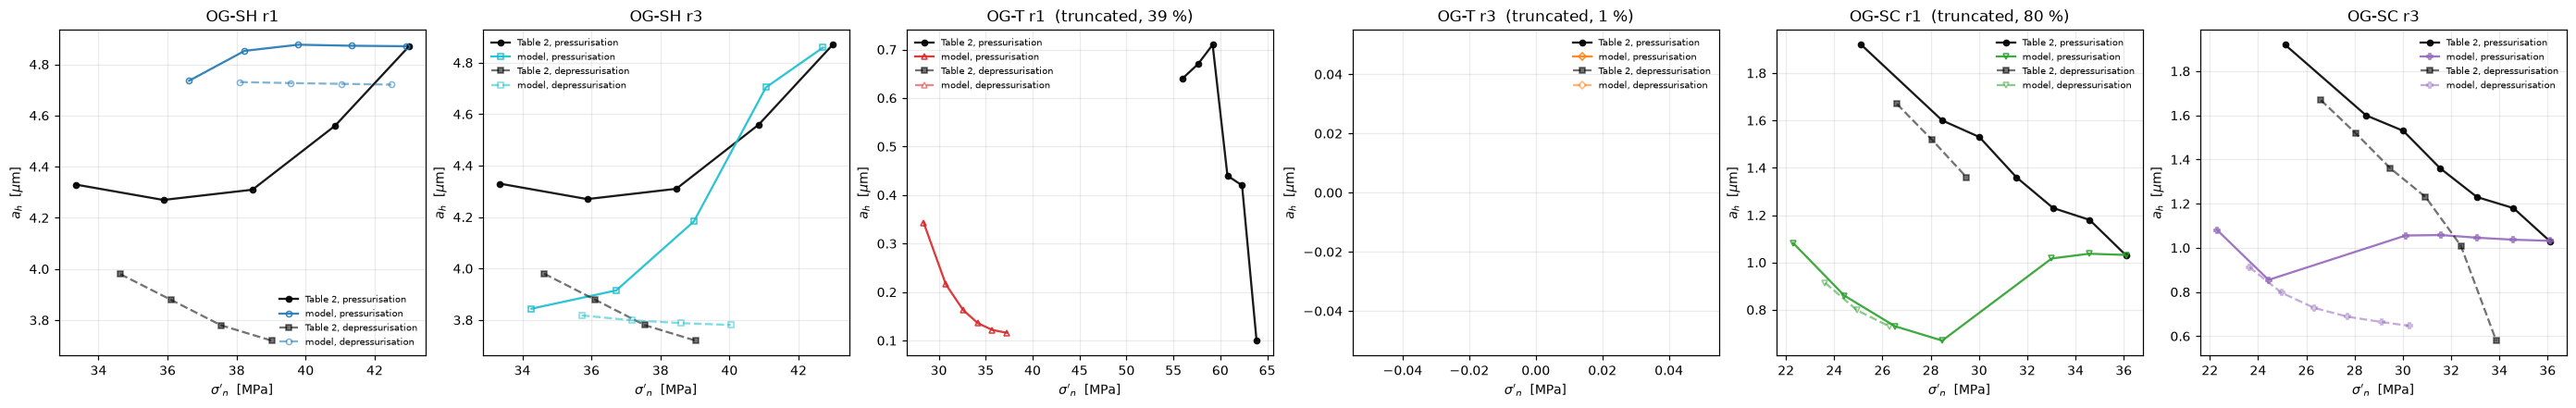

Measured a_h endpoints (stage 1 -> last):
  OG-SH   4.87 ->  3.72 um while sigma'_n went 42.99 -> 39.02 MPa
  OG-T    0.10 ->  0.00 um while sigma'_n went 63.86 -> 39.35 MPa
  OG-SC   1.03 ->  0.58 um while sigma'_n went 36.10 -> 33.87 MPa


In [54]:
fig, axes = plt.subplots(1, max(1, len(SHOWN)), figsize=(4.2 * max(1, len(SHOWN)), 3.9),
                         squeeze=False)
for ax, s in zip(axes.flat, SHOWN):
    cfg, tab = SHOWN[s], STAGE_TABLES[s]
    ref = REF[cfg["specimen"]]
    br = ref["branch"].to_numpy()[:len(tab)]
    for mask, style, lab in [(br == "pressurization", "-o", "pressurisation"),
                             (br == "depressurization", "--s", "depressurisation")]:
        ax.plot(tab["sn_meas"][mask], tab["ah_meas"][mask], style, ms=4, color="k",
                label=f"Table 2, {lab}", alpha=0.9 if style == "-o" else 0.55)
        # Branch line style still communicates pressurisation/depressurisation;
        # the run's marker and color keep multiple model variants distinguishable.
        branch_ls = "-" if lab == "pressurisation" else "--"
        ax.plot(tab["sn_sim"][mask], tab["ah_sim"][mask], ms=4, mfc="none",
                linestyle=branch_ls, marker=cfg["marker"], color=cfg["color"],
                label=f"model, {lab}", alpha=0.9 if branch_ls == "-" else 0.55)
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$a_h$  [$\mu$m]")
    ax.set_title(s if SHOWN[s]["complete"] else f"{s}  (truncated, {SHOWN[s]['pct']:.0f} %)")
    ax.legend(fontsize=6.5)
plt.show()

print("Measured a_h endpoints (stage 1 -> last):")
for s in SPECIMENS:
    r = REF[s]
    print(f"  {s:6s} {r['ah_um'].iloc[0]:5.2f} -> {r['ah_um'].iloc[-1]:5.2f} um "
          f"while sigma'_n went {r['sigma_n_MPa'].iloc[0]:5.2f} -> "
          f"{r['sigma_n_MPa'].iloc[-1]:5.2f} MPa")

## 11. Error summary

One panel per scored channel, stage on the x-axis. Reading it:

* a **flat offset** = a level error — loading gate, or an anchor constant;
* a **trend across stages** = a slope error — the constitutive law's stress dependence;
* a **step at one stage** = an event landing at the wrong time.

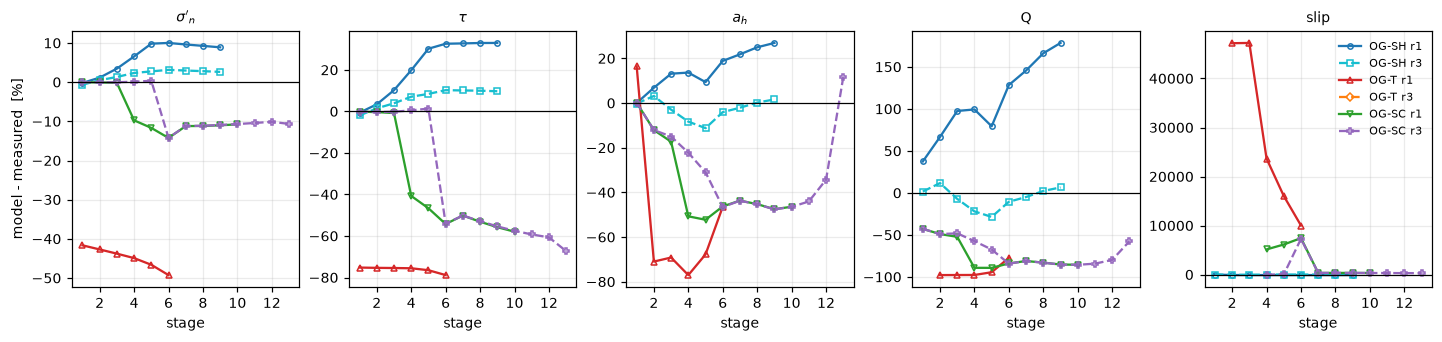

In [55]:
if STAGE_TABLES:
    labels = [("sn", r"$\sigma'_n$"), ("tau", r"$\tau$"), ("ah", r"$a_h$"),
              ("Q", "Q"), ("ds", "slip")]
    fig, axes = plt.subplots(1, len(labels), figsize=(2.6 * len(labels), 3.0), sharex=True)
    for ax, (lab, title) in zip(axes, labels):
        for s, tab in STAGE_TABLES.items():
            cfg = SHOWN[s]
            ax.plot(tab["stage"], tab[f"{lab}_err%"], ms=3.5,
                    color=cfg["color"], linestyle=cfg["linestyle"],
                    marker=cfg["marker"], mfc="none", label=s)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(title, fontsize=9); ax.set_xlabel("stage")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_ylabel("model - measured  [%]")
    axes[-1].legend(fontsize=7)
    plt.show()

## 12. What to check before believing a result

1. **Completeness** (§4) — a truncated CSV scores the early stages and looks merely bad.
2. **The frame check** (§5) — if `ds_mm` misses while `tau_MPa` is fine, the problem is
   `axial_bc_penalty`, not the joint law.
3. **The loading gate** — if τ is uniformly low at stage 1, `axial_pres_final` has not
   converged; re-derive it from `u_cmd = sigma_1/penalty + C_ax*(sigma_1 - sigma_3)`
   rather than scaling by eye.
4. **Sign of the aperture drift on OG-SH** (§10) — this is the specimen's whole result.
5. **Whether OG-SC bursts at all.** Stick-slip needs `D_c < d(tau)/k_eff`; the deck
   header prints both numbers.

Related documents:

* `doc/reading_kalantar2025_self_propping_granodiorite.md` — full reading notes and audit
* `doc/KALANTAR2025_VALIDATION_PLAN.md` — the plan and its gates
* `scripts/build_110_kalantar_decks.py` — where every deck constant comes from
* `scripts/kalantar_gate.py` — the scoring machinery imported above